**KS 2 Sample and KS 1 Sample test**

In [1]:
import numpy as np
from scipy.stats import ks_2samp, kstest, norm


# ============================================================
# 1. Example: Daily returns of two strategies
# ============================================================

strategy_a = np.array([
    0.012, 0.008, 0.015, -0.003, 0.010,
    0.007, -0.002, 0.013, 0.009, 0.011,
    0.006, 0.010, 0.004, 0.012, 0.008,
    0.014, 0.006, -0.004, 0.011, 0.009
])

strategy_b = np.array([
    0.005, 0.010, 0.004, 0.002, 0.006,
    0.003, 0.001, 0.005, 0.007, 0.004,
    0.003, 0.006, 0.005, 0.004, 0.006,
    0.002, 0.004, 0.003, 0.005, 0.004
])


alpha = 0.05


# ============================================================
# 2. Basic descriptive statistics
# ============================================================

print("=" * 60)
print("STRATEGY SUMMARY")
print("=" * 60)

print(f"Strategy A mean   : {np.mean(strategy_a):.4%}")
print(f"Strategy B mean   : {np.mean(strategy_b):.4%}")

print(f"Strategy A median : {np.median(strategy_a):.4%}")
print(f"Strategy B median : {np.median(strategy_b):.4%}")

print(f"Strategy A std    : {np.std(strategy_a, ddof=1):.4%}")
print(f"Strategy B std    : {np.std(strategy_b, ddof=1):.4%}")


# ============================================================
# 3. Function to make decision
# ============================================================

def make_decision(p_value, alpha=0.05):

    if p_value <= alpha:

        decision = "Reject H0"

        interpretation = (
            "There is statistically significant evidence "
            "against the null hypothesis."
        )

    else:

        decision = "Fail to reject H0"

        interpretation = (
            "There is insufficient statistical evidence "
            "to reject the null hypothesis."
        )

    return decision, interpretation


# ============================================================
# 4. TWO-SAMPLE KS TEST
# ============================================================

print("\n")
print("=" * 60)
print("TWO-SAMPLE KS TEST")
print("=" * 60)


# ------------------------------------------------------------
# A. Two-sided
# ------------------------------------------------------------

ks_stat, p_value = ks_2samp(
    strategy_a,
    strategy_b,
    alternative="two-sided"
)

decision, interpretation = make_decision(
    p_value,
    alpha
)

print("\n--- TWO-SIDED ---")

print(f"KS statistic : {ks_stat:.4f}")
print(f"p-value      : {p_value:.4f}")
print(f"Decision     : {decision}")
print(f"Interpretation: {interpretation}")


# ------------------------------------------------------------
# B. Strategy A has larger returns than B
# ------------------------------------------------------------

ks_stat, p_value = ks_2samp(
    strategy_a,
    strategy_b,
    alternative="less"
)

decision, interpretation = make_decision(
    p_value,
    alpha
)

print("\n--- ONE-SIDED: A > B ---")

print(f"KS statistic : {ks_stat:.4f}")
print(f"p-value      : {p_value:.4f}")
print(f"Decision     : {decision}")
print(f"Interpretation: {interpretation}")


# ------------------------------------------------------------
# C. Strategy A has smaller returns than B
# ------------------------------------------------------------

ks_stat, p_value = ks_2samp(
    strategy_a,
    strategy_b,
    alternative="greater"
)

decision, interpretation = make_decision(
    p_value,
    alpha
)

print("\n--- ONE-SIDED: A < B ---")

print(f"KS statistic : {ks_stat:.4f}")
print(f"p-value      : {p_value:.4f}")
print(f"Decision     : {decision}")
print(f"Interpretation: {interpretation}")


# ============================================================
# 5. ONE-SAMPLE KS TEST
# ============================================================

print("\n")
print("=" * 60)
print("ONE-SAMPLE KS TEST")
print("=" * 60)


# ------------------------------------------------------------
# Reference distribution
#
# Here we assume under H0:
#
# Returns ~ Normal(mean=0, std=1%)
#
# IMPORTANT:
# mean and std are specified externally here.
# They are NOT estimated from strategy_a.
# ------------------------------------------------------------

reference_mean = 0.00
reference_std = 0.01

reference_distribution = norm(
    loc=reference_mean,
    scale=reference_std
)


# ------------------------------------------------------------
# A. Two-sided
#
# H0: Strategy A follows the reference distribution
# H1: Strategy A does not follow the reference distribution
# ------------------------------------------------------------

ks_stat, p_value = kstest(
    strategy_a,
    reference_distribution.cdf,
    alternative="two-sided"
)

decision, interpretation = make_decision(
    p_value,
    alpha
)

print("\n--- ONE-SAMPLE: TWO-SIDED ---")

print(f"KS statistic : {ks_stat:.4f}")
print(f"p-value      : {p_value:.4f}")
print(f"Decision     : {decision}")
print(f"Interpretation: {interpretation}")


# ------------------------------------------------------------
# B. Strategy A tends to have larger returns
#
# alternative='less'
#
# Empirical CDF of A is lower than reference CDF.
# That means A tends to contain larger values.
# ------------------------------------------------------------

ks_stat, p_value = kstest(
    strategy_a,
    reference_distribution.cdf,
    alternative="less"
)

decision, interpretation = make_decision(
    p_value,
    alpha
)

print("\n--- ONE-SAMPLE: STRATEGY A > REFERENCE ---")

print(f"KS statistic : {ks_stat:.4f}")
print(f"p-value      : {p_value:.4f}")
print(f"Decision     : {decision}")
print(f"Interpretation: {interpretation}")


# ------------------------------------------------------------
# C. Strategy A tends to have smaller returns
#
# alternative='greater'
#
# Empirical CDF of A is higher than reference CDF.
# That means A tends to contain smaller values.
# ------------------------------------------------------------

ks_stat, p_value = kstest(
    strategy_a,
    reference_distribution.cdf,
    alternative="greater"
)

decision, interpretation = make_decision(
    p_value,
    alpha
)

print("\n--- ONE-SAMPLE: STRATEGY A < REFERENCE ---")

print(f"KS statistic : {ks_stat:.4f}")
print(f"p-value      : {p_value:.4f}")
print(f"Decision     : {decision}")
print(f"Interpretation: {interpretation}")

STRATEGY SUMMARY
Strategy A mean   : 0.7800%
Strategy B mean   : 0.4450%
Strategy A median : 0.9000%
Strategy B median : 0.4000%
Strategy A std    : 0.5425%
Strategy B std    : 0.2012%


TWO-SAMPLE KS TEST

--- TWO-SIDED ---
KS statistic : 0.6000
p-value      : 0.0011
Decision     : Reject H0
Interpretation: There is statistically significant evidence against the null hypothesis.

--- ONE-SIDED: A > B ---
KS statistic : 0.6000
p-value      : 0.0006
Decision     : Reject H0
Interpretation: There is statistically significant evidence against the null hypothesis.

--- ONE-SIDED: A < B ---
KS statistic : 0.1500
p-value      : 0.6437
Decision     : Fail to reject H0
Interpretation: There is insufficient statistical evidence to reject the null hypothesis.


ONE-SAMPLE KS TEST

--- ONE-SAMPLE: TWO-SIDED ---
KS statistic : 0.5257
p-value      : 0.0000
Decision     : Reject H0
Interpretation: There is statistically significant evidence against the null hypothesis.

--- ONE-SAMPLE: STRATEGY A > 

**A company wants know if black friday spendings of males follow a normal distribution.A sample of 30 males were asked about thier spendings and thier answers were recorded. Determine if this sample comes from normal distribution with 5% signinifance level.**

Q:Given two samples, how can we find whether they are follow same distribution or not?

Ans: Q-Q Plot can be used for graphically visualize how two distributions are ,but Q-Q plot cannot quantify how much different one distribution is to another. Therefore we cannot perform Hypothesis testing using Q-Q plot.

Q:Then how to measure the Similarity ?

The Kolmogorov-Smirnov test (KS-test) tries to determine if two datasets differ significantly. The KS-test has the advantage of making no assumption about the distribution of data

KS Test can be performed for two types of problems.

There's the one sample Kolmogorov-Smirnov test for testing if a variable follows a given distribution in a population. This “given distribution” is usually -not always- the normal distribution, hence “Kolmogorov-Smirnov normality test”.
There's also the independent samples Kolmogorov-Smirnov test for testing if a variable has identical distributions in 2 populations.

1. State the Null hypothesis that both the random variables come from same distribution
2. State the  Alternative hypothesis that both the random variables do not come from same distribution
3. Setup a confidence interval value
4. Calculate the D value using following formula $D_n,_m=Maximum|F_n(X)−F_m(X)|$
5. The null hypothesis is rejected at level $\alpha $ if $$D_{n,m} > c(\alpha) \sqrt(\frac{n+m}{nm})$$ where $c(\alpha)=\sqrt(-\frac{1}{2}log_e\alpha)$ <br> $n$,$m$ =number of points in samples.

### KS test in Python

KS Test in python can be performed using <b>scipy.stats.ks_2samp</b> api


  <h4><font color='blue'> Step 1:</font> <b>Stating Null Hypothesis and Alternate Hypothesis</b></h4>


<font color='brown'> Null Hypothesis $H_0$</font>:The black friday spendings of males follow a normal distribution.<br>
<font color='brown'> Alternative Hypothesis $H_a$</font>: The black friday spendings of males do not follow a normal distribution.

In [ ]:
# Taking one sample of size 500 from unknown disb
samples = np.array(random.sample(range(0, data_male.shape[0]), 30))
samples = (samples-samples.mean())/samples.std()

# Taking a sample of size 1000 from known disb
norm_samples=np.random.normal(loc=0.0, scale=1.0, size=30)
# norm_samples=(normal-normal.mean())/normal.std()

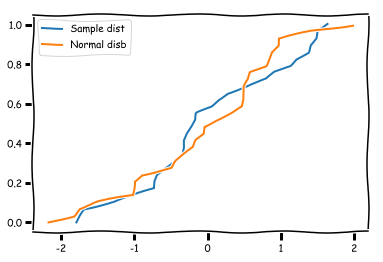

In [ ]:
sorted_data = np.sort(samples)
yvals=np.arange(len(sorted_data))/float(len(sorted_data)-1)


norm_sorted_data = np.sort(normal)
norm_yvals=np.arange(len(sorted_data))/float(len(sorted_data)-1)

plt.plot(sorted_data,yvals,label='Sample dist')
plt.plot(norm_sorted_data,norm_yvals,label='Normal disb')

plt.legend()
plt.show()

<font color='blue'> Step 2:</font> <b>Choosing significance level</b>

 Note that the significance level is  mentioned in the problem.<font color='red'> $$\alpha=0.05 $$</font>

<font color='blue'> Step 3:</font> <b>Calculating the test statistic</b>

<ul>
    <li>Here the test statistic we are dealing with is $D_N,_M$</li>
    <li> $D_N,_M$ is maximum distance between CDF of two distributions
</ul>

In [ ]:
#https://github.com/scipy/scipy/blob/v0.14.0/scipy/stats/stats.py#L3809
#sorting the data
data1 = np.sort(samples)
data2 = np.sort(norm_samples)
#storing the length of data
n1 = data1.shape[0]
n2 = data2.shape[0]
data_all = np.concatenate([data1, data2])
#calculating cdf
cdf1 = np.searchsorted(data1, data_all, side='right') / n1
cdf2 = np.searchsorted(data2, data_all, side='right') / n2
# d=max(abs(cdf1-cdf2))
d = np.max(np.absolute(cdf1 - cdf2))

In [ ]:
print('The test statictic d=',d)

The test statictic d= 0.16666666666666666


<h4> Calculating test statistic using scipy.stats api </h4>

In [ ]:
from scipy.stats import ks_2samp
d,p=ks_2samp(norm_samples,samples)

In [ ]:
print('The D value when calculated using scipy.stats api is',d ,'which is exactly equal to value we got')

The D value when calculated using scipy.stats api is 0.16666666666666666 which is exactly equal to value we got


In [ ]:
print('Corresponding P value for the D is ',p)

Corresponding P value for the D is  0.7600465102607563


<font color='blue'> Step 4:</font> <b>Comparing P value with Significance level</b>

<font> We can clearly observe that P value <font color='red'>0.75 > 0.05</font> and hence we <b>fail to reject the null </b> hypothesis $H_0$ that both the first sample come from normal distribution </font>

# From Live session

### KS-Test
We can do KS-Test to compare the distribution of PM and PW as follows.
- KS-Test uses the supremum of the gap between the distirbutions as the test-statistic.
- It also uses KS-distirbution to arrive at the probability-values.
- Permutaion+Resampling is completely non-parametric.

In [ ]:
# https://docs.scipy.org/doc/scipy-0.14.0/reference/generated/scipy.stats.ks_2samp.html
from scipy import stats

#1
n=100; # sample size
np.random.seed(100)
PM = np.random.pareto(a=5.0,size=n)
PW = np.random.pareto(a=4.0,size=n)

D,p = stats.ks_2samp(PW, PM)
print(D,p)

0.19 0.05390207893129876
